# Adjoint Solver for Spring-Slider Rate-and-State Friction

Extends the existing `springslider.ipynb` forward solver with an adjoint-based gradient computation.

**Setup:** Velocity-weakening friction (`a < b`), adaptive-step RK.

**State evolution:** Slip law — matches the existing forward solver exactly.

**Force balance convention:**
$$\tau(V,\psi) + \eta V + k u = \tau_L(t)$$

**Objective function (smoothed-slip misfit):**
$$J = \frac{1}{2}\int_0^T \left(Su - Su_{\rm obs}\right)^2 dt$$

where $S$ is a temporal Gaussian smoothing operator (row-normalised) and $u$ is the cumulative slip.

**Adjoint system** ($p = u^\dagger$, $r = \psi^\dagger$, BCs $p(T)=r(T)=0$)**:**

The system is a DAE. The Lagrangian introduces multipliers $p$, $r$ for the two ODEs and $\lambda$ for the algebraic force-balance constraint. Stationarity gives:

$$\delta u:\quad \dot{p} = k\lambda + \bigl[S^\top(Su - Su_{\rm obs})\bigr](t)$$
$$\delta\psi:\quad \dot{r} = \tau_\psi\,\lambda - G_\psi\,r$$
$$\delta V:\quad \lambda = \frac{p + G_V\,r}{\tau_V + \eta} \quad \text{(algebraic — no ODE)}$$

The adjoint solver integrates the $p,r$ ODEs **forwards in reversed time** $\tau = T - t$ and then re-inverts $\tau$ at the end.

**Gradient:**
$$\frac{dJ}{da} = \int_0^T \left[\lambda\,\frac{\partial\tau}{\partial a} - r\,\frac{\partial G}{\partial a}\right]dt$$

In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
import scipy.sparse

## Physics: Friction Law and Jacobians

**Regularised RS friction (slip-law form used in original code):**
$$\tau(V,\psi) = N a\,\sinh^{-1}\!\left(\frac{V}{2V_0}e^{\psi/a}\right)$$

**State evolution — slip law:**
$$G(V,\psi) = -\frac{V}{D_c}\left(\frac{\tau}{N} - f_{\rm ss}\right), \quad f_{\rm ss} = f_0 + (a-b)\ln(V/V_0)$$

Partial derivatives are derived analytically.

In [3]:
from friction_derivs import *

Physics functions defined.


## Parameters and Afterslip Initial Conditions

Velocity-strengthening (`a > b`) with a coseismic stress step $\Delta\tau$ at $t=0$.

In [4]:
# ------------------------------------------------------------------
# Parameters
# ------------------------------------------------------------------
M = {}
M['f0']  = 0.6
M['V0']  = 1e-6      # m/s reference velocity
M['a']   = 0.010     # direct effect  (a > b → velocity strengthening)
M['b']   = 0.015     # state evolution
M['dc']  = 1e-4      # m critical slip distance
M['N']   = 50.0      # MPa effective normal stress
M['eta'] = 2.7 * 3.5 / 2.0   # MPa·s/m radiation damping
# M['k']   = 2e4       # MPa/m spring stiffness
k_crit = M['N'] * (M['b'] - M['a']) / M['dc']
M['k'] = abs(0.9 * k_crit)

V_bg      = 1e-9     # m/s background / plate sliding rate
M['V_bg'] = V_bg

# ------------------------------------------------------------------
# Steady-state at V_bg
# ------------------------------------------------------------------
fss_bg = fss_fn(V_bg, M)
psi_ss = M['a'] * np.log(2.0 * M['V0'] / V_bg * np.sinh(fss_bg / M['a']))
tau_ss = M['N'] * fss_bg

# ------------------------------------------------------------------
# Initial conditions — V_init is the PRIMARY control parameter.
# tau0 is DERIVED from the force balance at t=0 (u=0):
#   tau(V_init, psi_init) + eta*V_init = tau0
# This ensures the forward solver starts at exactly V_init.
# ------------------------------------------------------------------
V_init   = 1.0e-12    # m/s  post-earthquake initial slip rate
psi_init = psi_ss    # pre-earthquake steady state at V_bg
u_init   = 0.0

M['tau0'] = tau_fn(V_init, psi_init, M) + M['eta'] * V_init
Delta_tau = M['tau0'] - tau_ss   # implied coseismic stress step (diagnostic)

# Characteristic afterslip time  T_c ~ N*a / (k * V_init)
T_c = M['N'] * M['a'] / (M['k'] * V_init)

print(f"a={M['a']}, b={M['b']}  →  velocity {'strengthening' if M['a']>M['b'] else 'weakening'}")
print(f"V_bg   = {V_bg:.2e} m/s,   V_init = {V_init:.2e} m/s  (ratio {V_init/V_bg:.1f}×)")
print(f"psi_ss = {psi_ss:.4f}")
print(f"tau_ss = {tau_ss:.4f} MPa")
print(f"tau0   = {M['tau0']:.4f} MPa  (Delta_tau = {Delta_tau:.4f} MPa)")
print(f"T_c    = {T_c:.3e} s  ({T_c/86400:.1f} days)")
print(f"k      = {M['k']:.2e} MPa/m,   k_crit = {k_crit:.2e} MPa/m  (k/k_crit = {M['k']/k_crit:.2f})")

a=0.01, b=0.015  →  velocity weakening
V_bg   = 1.00e-09 m/s,   V_init = 1.00e-12 m/s  (ratio 0.0×)
psi_ss = 0.7036
tau_ss = 31.7269 MPa
tau0   = 28.2731 MPa  (Delta_tau = -3.4539 MPa)
T_c    = 2.222e+08 s  (2572.0 days)
k      = 2.25e+03 MPa/m,   k_crit = 2.50e+03 MPa/m  (k/k_crit = 0.90)


## Adaptive Forward Solver

Uses a 3-stage embedded RK method (2nd/3rd-order pair) for automatic step-size control,
matching the MATLAB reference implementation.

**Method:** Three stages per trial step; accept if $\|[\Delta u,\,\Delta\psi]\|_2 < \text{tol}$;
adjust $\Delta t \leftarrow \sigma\,\Delta t\,(\text{tol}/e)^{1/3}$ where $\sigma=0.9$ is a safety factor.


In [5]:
from adapt_fwd_solve import *
# --- Run adaptive forward solve ---
T = 0.3*1e7    # s
print(f"Running adaptive forward solve: T={T:.1e} s ...")
fwd = forward_solve_adaptive(M, T, u_init, psi_init, V_init=V_init)
print(f"Done.  Steps={len(fwd['t'])-1},  V(0)={fwd['V'][0]:.6e},  V(T)={fwd['V'][-1]:.3e} m/s")
print(f"tau_L: {fwd['tau_L'][0]:.4f} → {fwd['tau_L'][-1]:.4f} MPa")


Running adaptive forward solve: T=3.0e+06 s ...
Done.  Steps=4300,  V(0)=1.000000e-12,  V(T)=4.508e-11 m/s
tau_L: 28.2731 → 35.0231 MPa


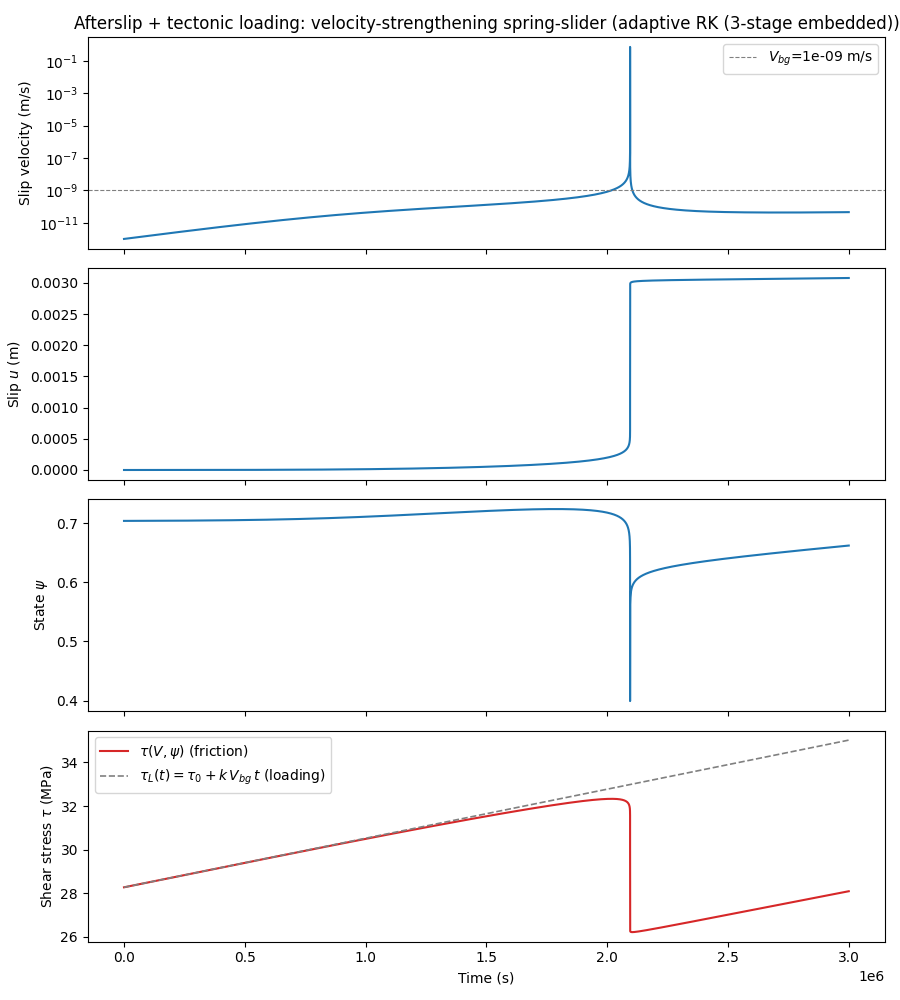

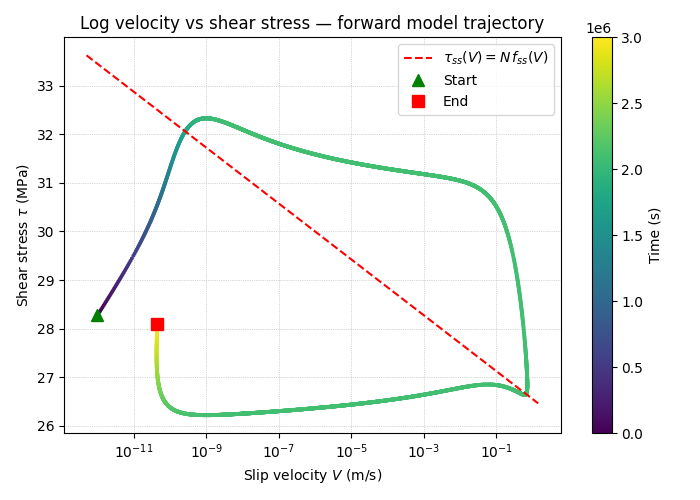

tau range: 26.2176 – 32.3308 MPa
V   range: 1.000e-12 – 7.089e-01 m/s


In [6]:
# ------------------------------------------------------------------
# Plot 1: Forward solution
# ------------------------------------------------------------------
tau_fwd = np.array([tau_fn(v, p, M) for v, p in zip(fwd['V'], fwd['psi'])])

fig, axes = plt.subplots(4, 1, figsize=(9, 10), sharex=True)

axes[0].plot(fwd['t'], fwd['V'])
axes[0].axhline(V_bg, color='gray', ls='--', lw=0.8, label=f'$V_{{bg}}$={V_bg:.0e} m/s')
axes[0].set_ylabel('Slip velocity (m/s)')
axes[0].set_yscale('log')
axes[0].set_title('Afterslip + tectonic loading: velocity-strengthening spring-slider (adaptive RK (3-stage embedded))')
axes[0].legend()

axes[1].plot(fwd['t'], fwd['u'])
axes[1].set_ylabel('Slip $u$ (m)')

axes[2].plot(fwd['t'], fwd['psi'])
axes[2].set_ylabel('State $\\psi$')

axes[3].plot(fwd['t'], tau_fwd, color='C3', label=r'$\tau(V,\psi)$ (friction)')
axes[3].plot(fwd['t'], fwd['tau_L'], color='gray', ls='--', lw=1.2,
             label=r'$\tau_L(t) = \tau_0 + k\,V_{bg}\,t$ (loading)')
axes[3].set_ylabel('Shear stress $\\tau$ (MPa)')
axes[3].set_xlabel('Time (s)')
axes[3].legend()

plt.tight_layout()
plt.show()


# ------------------------------------------------------------------
# Plot 1c: Log velocity vs shear stress (phase portrait)
# ------------------------------------------------------------------
V_min = fwd['V'].min() * 0.5
V_max = fwd['V'].max() * 2.0
V_ss  = np.geomspace(V_min, V_max, 300)
tau_ss_line = M['N'] * fss_fn(V_ss, M)

fig3, ax3 = plt.subplots(figsize=(7, 5))
sc = ax3.scatter(fwd['V'], tau_fwd, c=fwd['t'], cmap='viridis',
                 s=8, lw=0, zorder=3)
ax3.plot(V_ss, tau_ss_line, 'r--', lw=1.5, zorder=4,
         label=r'$\tau_{ss}(V) = N\,f_{ss}(V)$')
ax3.set_xscale('log')
ax3.set_ylabel('Shear stress $\\tau$ (MPa)')
ax3.set_xlabel('Slip velocity $V$ (m/s)')
ax3.set_title('Log velocity vs shear stress — forward model trajectory')
cbar = fig3.colorbar(sc, ax=ax3)
cbar.set_label('Time (s)')
ax3.plot(fwd['V'][0],  tau_fwd[0],  'g^', ms=8, zorder=5, label='Start')
ax3.plot(fwd['V'][-1], tau_fwd[-1], 'rs', ms=8, zorder=5, label='End')
ax3.legend()
ax3.grid(True, ls=':', lw=0.5, which='both')
plt.tight_layout()
plt.show()

print(f"tau range: {tau_fwd.min():.4f} – {tau_fwd.max():.4f} MPa")
print(f"V   range: {fwd['V'].min():.3e} – {fwd['V'].max():.3e} m/s")

In [7]:
# Smoothing length scale — 5% of the total simulation duration
sigma_smooth = 0.01 * T #0.08 * T
print(f"Smoothing σ = {sigma_smooth:.2e} s  ({sigma_smooth / 86400:.0f} days)")

Smoothing σ = 3.00e+04 s  (0 days)


## Adjoint Solver — Same Embedded RK with Linear Interpolation Within Step

We integrate the adjoint **forwards in reversed time** $\tau = T - t$ using the **same 3-stage embedded RK scheme** as the forward solver, stepping through the stored forward time grid in reverse order.

**Forward-state interpolation within each step:**  
The forward Jacobian coefficients $(\tau_V, \tau_\psi, G_V, G_\psi)$ and the smoothed misfit source $\mathrm{sm}$ are only stored at the grid nodes.  Within a step of size $\Delta\tau$ we linearly interpolate at fractional positions $\alpha \in \{0, \tfrac{1}{2}, 1\}$:
$$q(\alpha) = (1-\alpha)\,q_j + \alpha\,q_{j+1}$$

**RK stages** (adjoint RHS at reversed-time step $j\!\to\!j\!+\!1$, $\Delta\tau = t_j^{\rm rev} - t_{j+1}^{\rm rev} > 0$):
$$\mathbf{f}(p, r;\,\alpha) = \begin{pmatrix}
  -k\,\lambda - \mathrm{sm}(\alpha)\\
  -\tau_\psi(\alpha)\,\lambda + G_\psi(\alpha)\,r
\end{pmatrix}, \quad \lambda = \frac{p + G_V(\alpha)\,r}{\tau_V(\alpha)+\eta}$$

$$\mathbf{k}_1 = \mathbf{f}(y_j;\,\alpha{=}0), \quad
  \mathbf{k}_2 = \mathbf{f}\!\left(y_j+\tfrac{\Delta\tau}{2}\mathbf{k}_1;\,\alpha{=}\tfrac{1}{2}\right), \quad
  \mathbf{k}_3 = \mathbf{f}\!\left(y_j+\Delta\tau(-\mathbf{k}_1+2\mathbf{k}_2);\,\alpha{=}1\right)$$

**3rd-order update** (same weights as the forward solver):
$$y_{j+1} = y_j + \frac{\Delta\tau}{6}\!\left(\mathbf{k}_1 + 4\mathbf{k}_2 + \mathbf{k}_3\right)$$

At the end the arrays are reversed to recover $(p(t), r(t), \lambda(t))$ in original time order.

In [8]:
from adjoint_solve import *

print("Adjoint solver (3-stage embedded RK with linear forward-state interpolation) defined.")

Adjoint solver (3-stage embedded RK with linear forward-state interpolation) defined.


## Objective Function and Gradient

In [9]:
from compute_obj import *

# ------------------------------------------------------------------
# Generate synthetic observations at TRUE parameters
# ------------------------------------------------------------------
M_true = dict(M)
print("Generating synthetic u_obs with true a =", M_true['a'])
fwd_true  = forward_solve_adaptive(M_true, T, u_init, psi_init, V_init=V_init)
t_obs_arr = fwd_true['t']
u_obs     = fwd_true['u'].copy()
print(f"u_obs: u(0)={u_obs[0]:.4e} m,  u(T)={u_obs[-1]:.4e} m  ({len(t_obs_arr)} pts)")

# J_true = compute_J(fwd_true, t_obs_arr, u_obs, sigma_smooth)
# print(f"J at true parameters: {J_true:.2e}  (should be ~0)")

Generating synthetic u_obs with true a = 0.01
u_obs: u(0)=0.0000e+00 m,  u(T)=3.0801e-03 m  (4301 pts)


## Gradient Validation: Forward-Euler Adjoint vs Finite Differences

Before running the full adaptive-timestep gradient check, we first validate the adjoint equations on a **short time window** using a simple **Forward Euler** solver.

**Why FE first?**  Forward Euler is easy to reason about and very cheap.  
If the continuous adjoint equations are correct, the FE-adjoint gradient must agree with the FD gradient computed from FE forward solves (to within O(dt) discretisation error).  
We also overlay the FE and adaptive forward/adjoint solutions to verify they agree physically.

**Test setup:**
- Window: first characteristic timescale $T_c = N a/(k V_0)$  
- FE timestep: $T_c / 1000$ (well within the stability limit)  
- FD perturbation: centred difference, $\delta a = 10^{-5} a$

Test window : T_test  = 2.250e+06 s  (26.0 days)
FE timestep : dt      = 2.250e+02 s  =>  10000 steps
Checking gradient for parameter: 'a'
  Nominal a = 0.011  (1.1 × true = 0.01)
  FD perturbation: eps = 1.10e-07

[1/6] FE forward solve  (a = 0.011) ...
      10000 steps  |  V(T)=1.5010e-10 m/s  |  u(T)=1.5411e-03 m
[2/6] Adaptive RK forward solve ...
      1362 steps  |  V(T)=1.6518e-10 m/s  |  u(T)=1.4645e-03 m
[3/6] FE adjoint solve ...
[4/6] Adaptive adjoint solve ...
[5/6] FD gradient via FE  (eps = 1.10e-07) ...
[6/6] FD gradient via adaptive RK  (eps = 1.10e-07) ...

----------------------------------------------------------------------------
Quantity                                    FE forward    Adaptive fwd
----------------------------------------------------------------------------
J                                         8.081688e-03    1.047086e-02
dJ/da  (adjoint)                          2.781166e+02    3.261979e+01
dJ/da  (FD)                               5.210672e

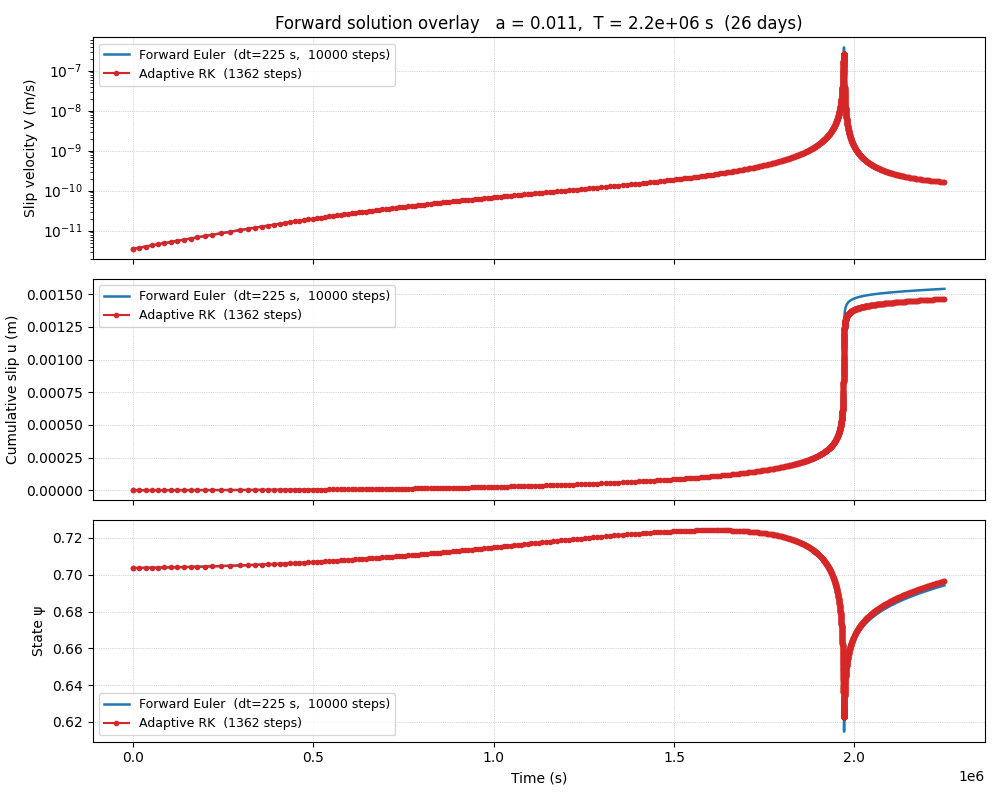

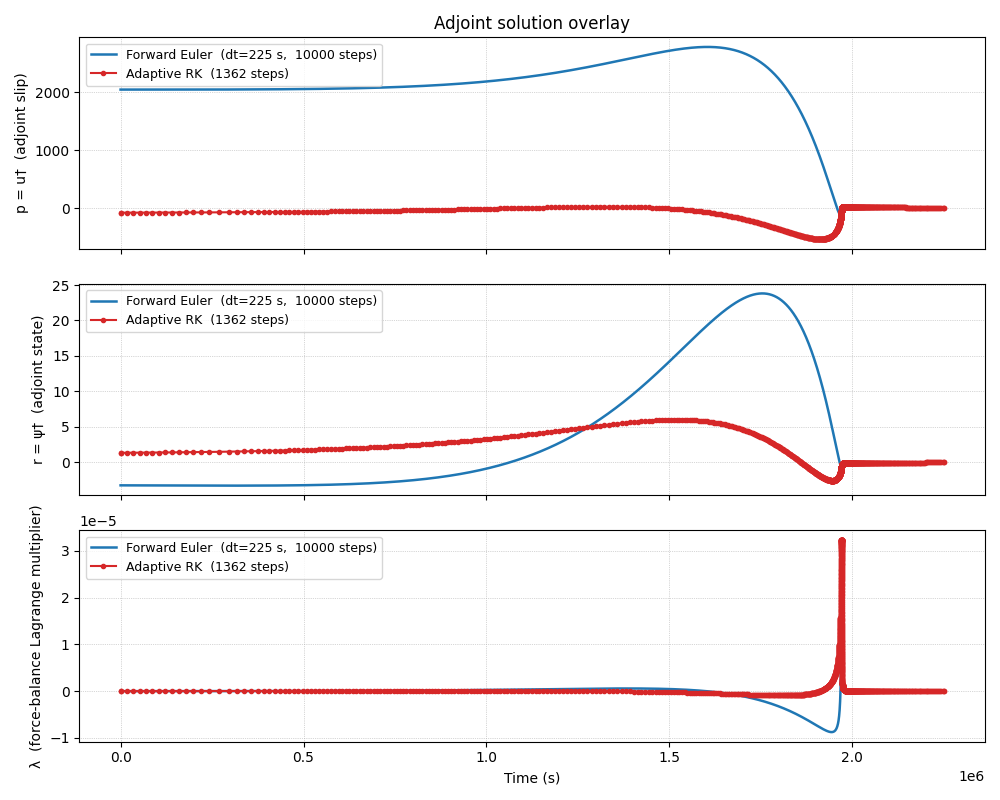

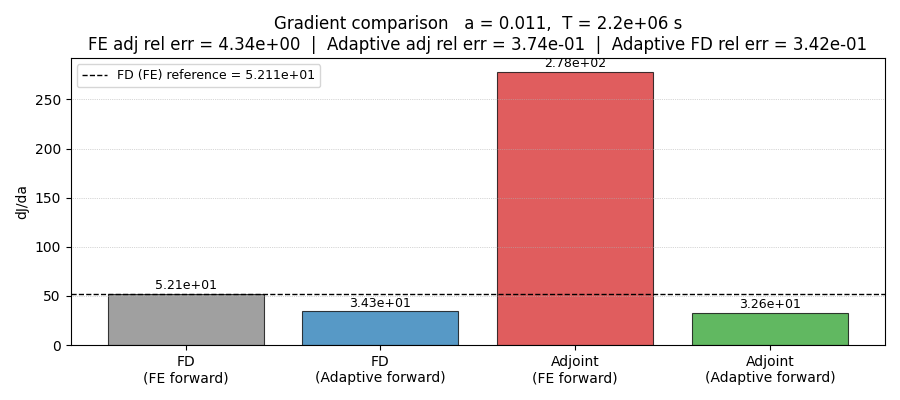

In [9]:
# ======================================================================
# VALIDATION: Adjoint gradient vs finite-difference gradient
#             + overlay of FE vs adaptive solutions
# ======================================================================

# ------------------------------------------------------------------
# Toggle: which parameter to validate the gradient for.
#   'a' — direct-effect friction parameter
#   'k' — spring stiffness
# ------------------------------------------------------------------
CHECK_PARAM = 'a'

# ------------------------------------------------------------------
# Gradient function registry — matches the inversion cell
# ------------------------------------------------------------------
_grad_fns_fd = {
    'a': compute_grad_a,
    'k': compute_grad_k,
}

# ------------------------------------------------------------------
# Smoothing matrix helpers
#
# fe_gaussian_S is a plain row-normalised Gaussian with no integration
# weights — correct for the uniform reference grid used below.
# make_smoothing_matrix (friction_derivs.py) applies trapezoidal weights
# and is kept here only to build per-solve S matrices for diagnostics.
# ------------------------------------------------------------------
def fe_gaussian_S(t, sigma):
    """Plain row-normalised Gaussian for a uniform grid."""
    if sigma == 0:
        return np.identity(len(t))
    diff2 = (t[:, None] - t[None, :]) ** 2 / (2.0 * sigma ** 2)
    S = np.exp(-diff2)
    S /= S.sum(axis=1, keepdims=True)
    return S

# ------------------------------------------------------------------
# Forward Euler solver (same dict structure as forward_solve_adaptive)
# ------------------------------------------------------------------
def forward_solve_euler(M, T, u0, psi0, dt, freeze=None):
    """
    Fixed-step Forward Euler forward solver.
    Returns the same dict structure as forward_solve_adaptive so it
    plugs directly into adjoint_solve / compute_J / compute_grad_a.

    freeze : iterable of str, optional
        Variables whose time derivatives are forced to zero.
        Supported values: 'u' (sets du/dt=0), 'psi' (sets dpsi/dt=0).
        Example: freeze={'psi'} disables state evolution.
    """
    freeze = set(freeze) if freeze is not None else set()
    tau_L_fn = lambda t: M['tau0'] + M['k'] * M['V_bg'] * t

    def _jac(V, psi):
        return (tau_V_fn(V, psi, M), tau_psi_fn(V, psi, M),
                G_V_fn(V, psi, M),   G_psi_fn(V, psi, M),
                dtau_da_fn(V, psi, M), dG_da_fn(V, psi, M))

    t = 0.0; u = u0; psi = psi0
    V0 = solve_V_algebraic(u0, psi0, M, tau_L_fn(0.0))
    j0 = _jac(V0, psi0)

    t_arr    = [0.0];     u_arr    = [u0];    psi_arr  = [psi0]
    V_arr    = [V0];      tauL_arr = [tau_L_fn(0.0)]
    tV_arr   = [j0[0]];   tP_arr   = [j0[1]]; GV_arr   = [j0[2]]
    GP_arr   = [j0[3]];   da_arr   = [j0[4]]; dGa_arr  = [j0[5]]

    while t < T - 1e-12 * T:
        dt_step = min(dt, T - t)
        V   = V_arr[-1]
        G   = G_fn(V, psi, M)

        du  = 0.0 if 'u'   in freeze else V
        dps = 0.0 if 'psi' in freeze else G

        u_new   = u   + dt_step * du
        psi_new = psi + dt_step * dps
        t_new   = t   + dt_step

        tL    = tau_L_fn(t_new)
        V_new = solve_V_algebraic(u_new, psi_new, M, tL)
        j     = _jac(V_new, psi_new)

        t_arr.append(t_new);    u_arr.append(u_new);    psi_arr.append(psi_new)
        V_arr.append(V_new);    tauL_arr.append(tL)
        tV_arr.append(j[0]);    tP_arr.append(j[1]);    GV_arr.append(j[2])
        GP_arr.append(j[3]);    da_arr.append(j[4]);    dGa_arr.append(j[5])

        t, u, psi = t_new, u_new, psi_new

    return dict(
        t       = np.array(t_arr),
        u       = np.array(u_arr),
        psi     = np.array(psi_arr),
        V       = np.array(V_arr),
        tau_L   = np.array(tauL_arr),
        tau_V   = np.array(tV_arr),
        tau_psi = np.array(tP_arr),
        G_V     = np.array(GV_arr),
        G_psi   = np.array(GP_arr),
        dtau_da = np.array(da_arr),
        dG_da   = np.array(dGa_arr),
    )

# ------------------------------------------------------------------
# Test window: first characteristic timescale T_c
# FE stability limit:  dt < 1 / max|G_psi| ~ dc/(V * tau_psi/N)
# ------------------------------------------------------------------
T_test   = T * 0.75
dt_euler = T_test / 10000.0
n_euler  = int(round(T_test / dt_euler))
print(f"Test window : T_test  = {T_test:.3e} s  ({T_test/86400:.1f} days)")
print(f"FE timestep : dt      = {dt_euler:.3e} s  =>  {n_euler} steps")
print(f"Checking gradient for parameter: '{CHECK_PARAM}'")

# Nominal model: true parameters with 10% offset in the checked param
M_fd = dict(M_true)
M_fd[CHECK_PARAM] = M_true[CHECK_PARAM] * 1.1

# FD perturbation size (relative)
eps_fd = abs(M_fd[CHECK_PARAM]) * 1e-5
M_p = dict(M_fd); M_p[CHECK_PARAM] = M_fd[CHECK_PARAM] + eps_fd
M_m = dict(M_fd); M_m[CHECK_PARAM] = M_fd[CHECK_PARAM] - eps_fd
print(f"  Nominal {CHECK_PARAM} = {M_fd[CHECK_PARAM]:.6g}  (1.1 × true = {M_true[CHECK_PARAM]:.6g})")
print(f"  FD perturbation: eps = {eps_fd:.2e}")

# da_fd kept for backward compatibility with the diagnostics cell below
da_fd = eps_fd

# Smoothing length for the validation window
sigma_test = 0.1 * T_test

# Observations clipped to [0, T_test]
mask_obs   = fwd_true['t'] <= T_test + 1.0
t_obs_test = fwd_true['t'][mask_obs]
u_obs_test = fwd_true['u'][mask_obs]

# ------------------------------------------------------------------
# Fixed reference grid — same approach as the inversion cell.
# All forward solutions have u interpolated here before the smoothed
# residual is computed.  This makes J and the adjoint source consistent
# across solvers and perturbations, eliminating grid-variation artefacts
# in FD gradients.  Physics quantities (tau_V etc.) stay on each
# solver's native grid so the adjoint keeps full time resolution.
# ------------------------------------------------------------------
t_ref_fd     = np.linspace(0.0, T_test,
                           min(int(T_test / ((sigma_test + 0.01) / 20)) + 1, 5000))
S_fixed_fd   = fe_gaussian_S(t_ref_fd, sigma_test)   # uniform grid → plain Gaussian
u_obs_ref_fd = np.interp(t_ref_fd, t_obs_test, u_obs_test)

def _J_fd_fixed(u_native, t_native):
    """J on fixed reference grid: interpolate u, then compute smoothed residual."""
    u_ref = np.interp(t_ref_fd, t_native, u_native)
    return 0.5 * np.trapz((S_fixed_fd @ u_ref - S_fixed_fd @ u_obs_ref_fd)**2, t_ref_fd)

def _sm_native(fwd):
    """Adjoint misfit source on fwd's native grid, consistent with _J_fd_fixed."""
    u_ref        = np.interp(t_ref_fd, fwd['t'], fwd['u'])
    residual_ref = S_fixed_fd @ u_ref - S_fixed_fd @ u_obs_ref_fd
    sm_ref       = S_fixed_fd.T @ residual_ref
    return np.interp(fwd['t'], t_ref_fd, sm_ref)

# ------------------------------------------------------------------
# Step 1 & 2: forward solves
# ------------------------------------------------------------------
print(f"\n[1/6] FE forward solve  ({CHECK_PARAM} = {M_fd[CHECK_PARAM]:.5g}) ...")
fwd_fe = forward_solve_euler(M_fd, T_test, u_init, psi_init, dt_euler)
print(f"      {len(fwd_fe['t'])-1} steps  |  V(T)={fwd_fe['V'][-1]:.4e} m/s  |  u(T)={fwd_fe['u'][-1]:.4e} m")

print(f"[2/6] Adaptive RK forward solve ...")
fwd_ad = forward_solve_adaptive(M_fd, T_test, u_init, psi_init)
print(f"      {len(fwd_ad['t'])-1} steps  |  V(T)={fwd_ad['V'][-1]:.4e} m/s  |  u(T)={fwd_ad['u'][-1]:.4e} m")

# Per-solve smoothing matrices — kept for the diagnostics cell below
if sigma_test != 0:
    S_fe = fe_gaussian_S(fwd_fe['t'], sigma_test)
    S_ad = make_smoothing_matrix(fwd_ad['t'], sigma_test)
else:
    S_fe = S_ad = None

J_fe = _J_fd_fixed(fwd_fe['u'], fwd_fe['t'])
J_ad = _J_fd_fixed(fwd_ad['u'], fwd_ad['t'])

# ------------------------------------------------------------------
# Step 3 & 4: adjoint solves
# Misfit source is built on the fixed reference grid and interpolated
# back to each solver's native grid — matching how J is evaluated.
# ------------------------------------------------------------------
print(f"[3/6] FE adjoint solve ...")
adj_fe      = adjoint_solve(fwd_fe, None, None, M_fd, sigma_test,
                            smooth_misfit=_sm_native(fwd_fe))
grad_adj_fe = _grad_fns_fd[CHECK_PARAM](fwd_fe, adj_fe, M_fd)

print(f"[4/6] Adaptive adjoint solve ...")
adj_ad      = adjoint_solve(fwd_ad, None, None, M_fd, sigma_test,
                            smooth_misfit=_sm_native(fwd_ad))
grad_adj_ad = _grad_fns_fd[CHECK_PARAM](fwd_ad, adj_ad, M_fd)

# ------------------------------------------------------------------
# Step 5: FD gradient — FE forward solves
# FE perturbed solves share the same uniform grid, so _J_fd_fixed is
# equivalent to direct evaluation, but kept for consistency.
# ------------------------------------------------------------------
print(f"[5/6] FD gradient via FE  (eps = {eps_fd:.2e}) ...")
fwd_fe_p = forward_solve_euler(M_p, T_test, u_init, psi_init, dt_euler)
fwd_fe_m = forward_solve_euler(M_m, T_test, u_init, psi_init, dt_euler)
J_p_fe   = _J_fd_fixed(fwd_fe_p['u'], fwd_fe_p['t'])
J_m_fe   = _J_fd_fixed(fwd_fe_m['u'], fwd_fe_m['t'])
grad_fd_fe = (J_p_fe - J_m_fe) / (2.0 * eps_fd)

# ------------------------------------------------------------------
# Step 6: FD gradient — adaptive forward solves
# Fixed-grid J removes the grid-variation artefact that previously
# caused adaptive FD to disagree with the adjoint.
# ------------------------------------------------------------------
print(f"[6/6] FD gradient via adaptive RK  (eps = {eps_fd:.2e}) ...")
fwd_p = forward_solve_adaptive(M_p, T_test, u_init, psi_init)
fwd_m = forward_solve_adaptive(M_m, T_test, u_init, psi_init)
# Per-solve smoothing matrices kept for diagnostics cell below
S_p = make_smoothing_matrix(fwd_p['t'], sigma_test) if sigma_test != 0 else None
S_m = make_smoothing_matrix(fwd_m['t'], sigma_test) if sigma_test != 0 else None
J_p_ad   = _J_fd_fixed(fwd_p['u'], fwd_p['t'])
J_m_ad   = _J_fd_fixed(fwd_m['u'], fwd_m['t'])
grad_fd_ad = (J_p_ad - J_m_ad) / (2.0 * eps_fd)

# Reference gradient for downstream cells
grad_fd = grad_fd_fe

# ------------------------------------------------------------------
# Summary table
# ------------------------------------------------------------------
rel_fe    = abs(grad_adj_fe - grad_fd_fe) / (abs(grad_fd_fe) + 1e-30)
rel_ad    = abs(grad_adj_ad - grad_fd_fe) / (abs(grad_fd_fe) + 1e-30)
rel_fd_ad = abs(grad_fd_ad  - grad_fd_fe) / (abs(grad_fd_fe) + 1e-30)

p = CHECK_PARAM
print(f"\n{'':->76}")
print(f"{'Quantity':<38}  {'FE forward':>14}  {'Adaptive fwd':>14}")
print(f"{'':->76}")
print(f"{'J':<38}  {J_fe:14.6e}  {J_ad:14.6e}")
print(f"{f'dJ/d{p}  (adjoint)':<38}  {grad_adj_fe:14.6e}  {grad_adj_ad:14.6e}")
print(f"{f'dJ/d{p}  (FD)':<38}  {grad_fd_fe:14.6e}  {grad_fd_ad:14.6e}")
print(f"{'relative error vs FD (FE)':<38}  {rel_fe:14.2e}  {rel_ad:14.2e}")
print(f"{'PASS / FAIL  (< 5 %)':<38}  {'PASS' if rel_fe < 0.05 else 'FAIL':>14}  "
      f"{'PASS' if rel_ad < 0.05 else 'FAIL':>14}")
print(f"{'FD (adaptive) vs FD (FE) rel err':<38}  {'—':>14}  {rel_fd_ad:14.2e}")
print(f"{'':->76}")

# ======================================================================
# Plot A — Forward solution overlay (V, u, psi)
# ======================================================================
kw_fe = dict(color='C0', lw=1.8,  label=f'Forward Euler  (dt={dt_euler:.0f} s,  {n_euler} steps)')
kw_ad = dict(color='C3', marker='.', label=f'Adaptive RK  ({len(fwd_ad["t"])-1} steps)')

fig_a, axs_a = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axs_a[0].semilogy(fwd_fe['t'], fwd_fe['V'], **kw_fe)
axs_a[0].semilogy(fwd_ad['t'], fwd_ad['V'], **kw_ad)
axs_a[0].set_ylabel('Slip velocity V (m/s)')
axs_a[0].set_title(f'Forward solution overlay   {p} = {M_fd[p]:.5g},  '
                   f'T = {T_test:.1e} s  ({T_test/86400:.0f} days)')
axs_a[0].legend(fontsize=9); axs_a[0].grid(True, ls=':', lw=0.5)

axs_a[1].plot(fwd_fe['t'], fwd_fe['u'], **kw_fe)
axs_a[1].plot(fwd_ad['t'], fwd_ad['u'], **kw_ad)
axs_a[1].set_ylabel('Cumulative slip u (m)')
axs_a[1].legend(fontsize=9); axs_a[1].grid(True, ls=':', lw=0.5)

axs_a[2].plot(fwd_fe['t'], fwd_fe['psi'], **kw_fe)
axs_a[2].plot(fwd_ad['t'], fwd_ad['psi'], **kw_ad)
axs_a[2].set_ylabel('State ψ')
axs_a[2].set_xlabel('Time (s)')
axs_a[2].legend(fontsize=9); axs_a[2].grid(True, ls=':', lw=0.5)

plt.tight_layout()
plt.show()

# ======================================================================
# Plot B — Adjoint solution overlay (p, r, λ)
# ======================================================================
fig_b, axs_b = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axs_b[0].plot(adj_fe['t'], adj_fe['p'], **kw_fe)
axs_b[0].plot(adj_ad['t'], adj_ad['p'], **kw_ad)
axs_b[0].set_ylabel('p = u†  (adjoint slip)')
axs_b[0].set_title('Adjoint solution overlay')
axs_b[0].legend(fontsize=9); axs_b[0].grid(True, ls=':', lw=0.5)

axs_b[1].plot(adj_fe['t'], adj_fe['r'], **kw_fe)
axs_b[1].plot(adj_ad['t'], adj_ad['r'], **kw_ad)
axs_b[1].set_ylabel('r = ψ†  (adjoint state)')
axs_b[1].legend(fontsize=9); axs_b[1].grid(True, ls=':', lw=0.5)

axs_b[2].plot(adj_fe['t'], adj_fe['lam'], **kw_fe)
axs_b[2].plot(adj_ad['t'], adj_ad['lam'], **kw_ad)
axs_b[2].set_ylabel('λ  (force-balance Lagrange multiplier)')
axs_b[2].set_xlabel('Time (s)')
axs_b[2].legend(fontsize=9); axs_b[2].grid(True, ls=':', lw=0.5)

plt.tight_layout()
plt.show()

# ======================================================================
# Plot C — Gradient bar chart
# ======================================================================
fig_c, ax_c = plt.subplots(figsize=(9, 4))
labels_c = [f'FD\n(FE forward)', f'FD\n(Adaptive forward)',
            f'Adjoint\n(FE forward)', f'Adjoint\n(Adaptive forward)']
vals_c   = [grad_fd_fe, grad_fd_ad, grad_adj_fe, grad_adj_ad]
colors_c = ['gray', 'C0', 'C3', 'C2']
bars_c   = ax_c.bar(labels_c, vals_c, color=colors_c, alpha=0.75, edgecolor='k', lw=0.8)
ax_c.axhline(grad_fd_fe, color='k', ls='--', lw=1.0,
             label=f'FD (FE) reference = {grad_fd_fe:.3e}')

for bar, v in zip(bars_c, vals_c):
    offset = 0.03 * abs(grad_fd_fe)
    va = 'bottom' if v >= 0 else 'top'
    y  = v + (offset if v >= 0 else -offset)
    ax_c.text(bar.get_x() + bar.get_width() / 2, y, f'{v:.2e}',
              ha='center', va=va, fontsize=9)

ax_c.set_ylabel(f'dJ/d{p}')
ax_c.set_title(f'Gradient comparison   {p} = {M_fd[p]:.5g},  T = {T_test:.1e} s\n'
               f'FE adj rel err = {rel_fe:.2e}  |  Adaptive adj rel err = {rel_ad:.2e}  |  '
               f'Adaptive FD rel err = {rel_fd_ad:.2e}')
ax_c.legend(fontsize=9)
ax_c.grid(True, ls=':', lw=0.5, axis='y')
plt.tight_layout()
plt.show()



Landscape: a  (true = 0.01)
Caching 34 forward solves ...
  [8/34]  a=0.0081667
  [16/34]  a=0.0096
  [24/34]  a=0.011273
  [32/34]  a=0.013455
  [34/34]  a=0.014

Evaluating J (time-shift OFF) ...

Computing adjoint gradients (time-shift OFF) ...
  No smoothing (identi  [8/34]  a=0.0081667  grad=-3.231e+09
  No smoothing (identi  [16/34]  a=0.0096  grad=-6.739e+08
  No smoothing (identi  [24/34]  a=0.011273  grad=-3.726e+02
  No smoothing (identi  [32/34]  a=0.013455  grad=-9.869e+02
  No smoothing (identi  [34/34]  a=0.014  grad=-1.015e+03
  Medium  ($\sigma$ =   [8/34]  a=0.0081667  grad=5.373e+08
  Medium  ($\sigma$ =   [16/34]  a=0.0096  grad=2.371e+09
  Medium  ($\sigma$ =   [24/34]  a=0.011273  grad=-1.260e+02
  Medium  ($\sigma$ =   [32/34]  a=0.013455  grad=-1.013e+03
  Medium  ($\sigma$ =   [34/34]  a=0.014  grad=-1.045e+03
  Heavy   ($\sigma$ =   [8/34]  a=0.0081667  grad=-4.989e+09
  Heavy   ($\sigma$ =   [16/34]  a=0.0096  grad=-1.617e+09
  Heavy   ($\sigma$ =   [24/34]  

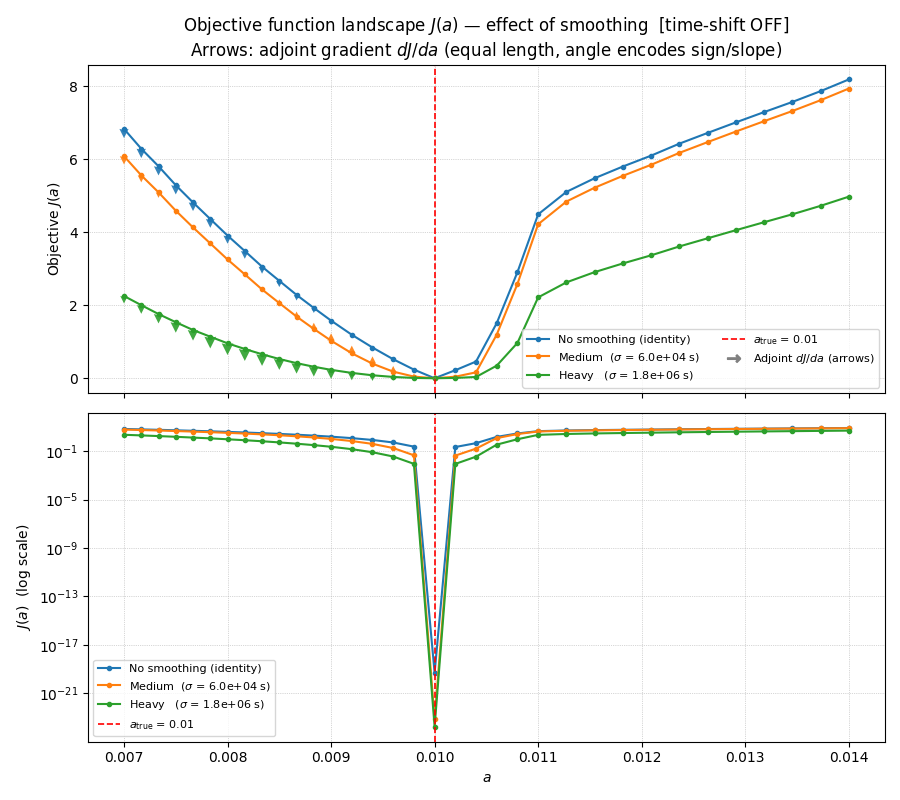


No smoothing (identity)                             min J = 5.016e-20  at a = 0.01
Medium  ($\sigma$ = 6.0e+04 s)                      min J = 6.932e-24  at a = 0.01
Heavy   ($\sigma$ = 1.8e+06 s)                      min J = 1.735e-24  at a = 0.01


In [24]:
from scipy.optimize import minimize_scalar

# ------------------------------------------------------------------
# TOGGLE: choose which parameters to map out the landscape for.
# Options: ['a'], ['k'], or ['a', 'k']
# ------------------------------------------------------------------
LANDSCAPE_PARAMS = ['a']

# ------------------------------------------------------------------
# TOGGLE: set True to marginalise over a time shift for each (a, sigma)
#         before computing J and the adjoint gradient.
# ------------------------------------------------------------------
USE_TIME_SHIFT      = False
TIME_SHIFT_MAX_FRAC = 0.25   # search window = ± 25 % of total T

# ------------------------------------------------------------------
# Helpers
# ------------------------------------------------------------------
def gaussian_S(t, sigma):
    diff2 = (t[:, None] - t[None, :]) ** 2 / (2.0 * sigma ** 2)
    S = np.exp(-diff2)
    S /= S.sum(axis=1, keepdims=True)
    return S

def _eval_J_landscape(fwd, u_obs_on_fwd, sigma):
    if sigma is None:
        return 0.5 * np.trapz((fwd['u'] - u_obs_on_fwd) ** 2, fwd['t'])
    S      = make_smoothing_matrix(fwd['t'], sigma)
    Su     = S @ fwd['u']
    Su_obs = S @ u_obs_on_fwd
    return 0.5 * np.trapz((Su - Su_obs) ** 2, fwd['t'])

def compute_J_landscape(fwd, t_obs, u_obs, sigma, delta_t=0.0):
    u_obs_on_fwd = np.interp(fwd['t'] + delta_t, t_obs, u_obs,
                              left=u_obs[0], right=u_obs[-1])
    return _eval_J_landscape(fwd, u_obs_on_fwd, sigma)

def find_optimal_shift_landscape(fwd, t_obs, u_obs, sigma):
    T_span = t_obs[-1] - t_obs[0]
    bound  = TIME_SHIFT_MAX_FRAC * T_span
    res = minimize_scalar(
        lambda dt: compute_J_landscape(fwd, t_obs, u_obs, sigma, dt),
        bounds=(-bound, bound), method='bounded',
        options={'xatol': T_span * 1e-5},
    )
    return res.x, res.fun

def setup_initial_conditions(M):
    fss_bg = fss_fn(M['V_bg'], M)
    psi_ss = M['a'] * np.log(2.0 * M['V0'] / M['V_bg'] * np.sinh(fss_bg / M['a']))
    V_init = 1.0e-12
    M['tau0'] = tau_fn(V_init, psi_ss, M) + M['eta'] * V_init
    return 0.0, psi_ss, V_init

# Three smoothing levels
sigma_medium = 0.01 * T
sigma_heavy  = 0.3  * T

smoothing_cases = [
    ('No smoothing (identity)',                       None,         'C0'),
    (f'Medium  ($\\sigma$ = {sigma_medium:.1e} s)',   sigma_medium, 'C1'),
    (f'Heavy   ($\\sigma$ = {sigma_heavy:.1e} s)',    sigma_heavy,  'C2'),
]

# ------------------------------------------------------------------
# Scan configuration for each supported parameter
# ------------------------------------------------------------------
_scan_config = {
    'a': {
        'vals': np.concatenate([
            np.linspace(0.7 * M_true['a'], 0.9 * M_true['a'], 12, endpoint=False),
            np.linspace(0.9 * M_true['a'], 1.1 * M_true['a'], 10, endpoint=False),
            np.linspace(1.1 * M_true['a'], 1.4 * M_true['a'], 12),
        ]),
        'true_val': M_true['a'],
        'xlabel':   '$a$',
        'title_J':  '$J(a)$',
        'grad_fn':  compute_grad_a,
    },
    'k': {
        'vals':     np.linspace(0.5 * k_crit, 1.3 * k_crit, 34),
        'true_val': M_true['k'],
        'xlabel':   '$k$  (Pa/m)',
        'title_J':  '$J(k)$',
        'grad_fn':  compute_grad_k,
    },
}

ts_tag = 'time-shift ON' if USE_TIME_SHIFT else 'time-shift OFF'

# ------------------------------------------------------------------
# Loop over each requested landscape parameter
# ------------------------------------------------------------------
for scan_param in LANDSCAPE_PARAMS:
    cfg     = _scan_config[scan_param]
    p_scan  = cfg['vals']
    p_true  = cfg['true_val']
    grad_fn = cfg['grad_fn']

    print(f"\n{'='*60}")
    print(f"Landscape: {scan_param}  (true = {p_true:.5g})")
    print(f"Caching {len(p_scan)} forward solves ...")

    fwd_cache = []
    for i, p_val in enumerate(p_scan):
        Mc = dict(M_true)
        Mc[scan_param] = p_val
        u0_ls, psi0_ls, _ = setup_initial_conditions(Mc)
        try:
            fwd_s = forward_solve_adaptive(Mc, T, u0_ls, psi0_ls)
        except Exception as e:
            fwd_s = None
            print(f"  {scan_param}={p_val:.5g} failed: {e}")
        fwd_cache.append(fwd_s)
        if (i + 1) % 8 == 0 or i == len(p_scan) - 1:
            print(f"  [{i+1}/{len(p_scan)}]  {scan_param}={p_val:.5g}")

    # Evaluate J
    J_results  = {}
    dt_results = {}
    print(f"\nEvaluating J ({ts_tag}) ...")
    for label, sigma, _ in smoothing_cases:
        J_arr  = []
        dt_arr = []
        for fwd_s in fwd_cache:
            if fwd_s is None:
                J_arr.append(np.nan); dt_arr.append(np.nan); continue
            if USE_TIME_SHIFT:
                dt_opt, J_val = find_optimal_shift_landscape(fwd_s, t_obs_arr, u_obs, sigma)
            else:
                dt_opt = 0.0
                J_val  = compute_J_landscape(fwd_s, t_obs_arr, u_obs, sigma, delta_t=0.0)
            J_arr.append(J_val); dt_arr.append(dt_opt)
        J_results[label]  = np.array(J_arr)
        dt_results[label] = np.array(dt_arr)

    # Adjoint gradient
    print(f"\nComputing adjoint gradients ({ts_tag}) ...")
    grad_results = {}
    for label, sigma, color in smoothing_cases:
        grad_arr = []
        for i, p_val in enumerate(p_scan):
            fwd_s_cached = fwd_cache[i]
            if fwd_s_cached is None:
                grad_arr.append(np.nan); continue
            Mc = dict(M_true)
            Mc[scan_param] = p_val
            u0_ls, psi0_ls, _ = setup_initial_conditions(Mc)
            try:
                fwd_s = forward_solve_adaptive(Mc, T, u0_ls, psi0_ls)
            except Exception as e:
                grad_arr.append(np.nan)
                print(f"  {scan_param}={p_val:.5g} failed: {e}")
                continue
            delta_t = dt_results[label][i] if USE_TIME_SHIFT else 0.0
            u_obs_eff = np.interp(fwd_s['t'] + delta_t, t_obs_arr, u_obs,
                                   left=u_obs[0], right=u_obs[-1])
            try:
                adj_s = adjoint_solve(fwd_s, fwd_s['t'], u_obs_eff, Mc, sigma)
                g = grad_fn(fwd_s, adj_s, Mc)
            except Exception:
                g = np.nan
            grad_arr.append(g)
            if (i + 1) % 8 == 0 or i == len(p_scan) - 1:
                print(f"  {label[:20]:20s}  [{i+1}/{len(p_scan)}]  "
                      f"{scan_param}={p_val:.5g}  grad={grad_arr[-1]:.3e}"
                      + (f"  Dt={delta_t/86400:.2f} d" if USE_TIME_SHIFT else ""))
        grad_results[label] = np.array(grad_arr)

    # Plot
    n_rows = 3 if USE_TIME_SHIFT else 2
    fig, axes = plt.subplots(n_rows, 1, figsize=(9, 4 * n_rows), sharex=True)

    for label, sigma, color in smoothing_cases:
        J_arr = J_results[label]
        J_pos = np.where(J_arr > 0, J_arr, np.nan)
        axes[0].plot(p_scan, J_arr,  'o-', ms=3, lw=1.5, color=color, label=label)
        axes[1].semilogy(p_scan, J_pos, 'o-', ms=3, lw=1.5, color=color, label=label)

    p_range = p_scan[-1] - p_scan[0]
    all_J   = np.concatenate([J_results[lbl] for lbl, _, _ in smoothing_cases])
    J_range = np.nanmax(all_J) - np.nanmin(all_J)
    arrow_frac = 0.04

    # Global max |g| so all smoothing cases share the same magnitude scale
    g_global_max = max(
        np.nanmax(np.abs(grad_results[lbl])) for lbl, _, _ in smoothing_cases
    )

    for label, sigma, color in smoothing_cases:
        J_arr = J_results[label]
        g_arr = grad_results[label]
        valid = ~np.isnan(g_arr) & ~np.isnan(J_arr)
        p_v, J_v, g_v = p_scan[valid], J_arr[valid], g_arr[valid]

        # Slope direction (1, g) in data coords, normalised to axis-fraction space
        # so the visual angle reflects the true slope of the J(p) curve.
        hat_x = 1.0 / p_range             # unit step in normalised x
        hat_y = g_v / J_range             # corresponding y in normalised space
        mag_hat = np.sqrt(hat_x**2 + hat_y**2)

        # Scale arrow length by |g| / g_global_max so magnitude is visible.
        rel_mag = np.abs(g_v) / g_global_max
        U     = arrow_frac * (hat_x / mag_hat) * rel_mag * p_range
        V_arr = arrow_frac * (hat_y / mag_hat) * rel_mag * J_range

        axes[0].quiver(p_v, J_v, U, V_arr,
                       color=color, scale=1, scale_units='xy', angles='xy',
                       width=0.003, headwidth=5, headlength=5, zorder=5, alpha=0.9)

    if USE_TIME_SHIFT:
        for label, sigma, color in smoothing_cases:
            dt_arr = dt_results[label] / 86400
            valid  = ~np.isnan(dt_arr)
            axes[2].plot(p_scan[valid], dt_arr[valid], 'o-', ms=3, lw=1.5,
                         color=color, label=label)
        axes[2].axhline(0, color='k', ls='--', lw=0.8)
        axes[2].set_ylabel('Optimal $\\Delta t$ (days)')
        axes[2].legend(fontsize=8)
        axes[2].grid(True, ls=':', lw=0.5, which='both')

    proxy = plt.Line2D([0], [0], marker=r'$\rightarrow$', color='gray',
                       linestyle='none', markersize=10,
                       label=f'Adjoint $dJ/d{scan_param}$ (arrows)')

    for ax in axes[:2]:
        ax.axvline(p_true, color='red', ls='--', lw=1.2,
                   label=f'${scan_param}_{{\\rm true}}$ = {p_true:.5g}')
        handles, lbls = ax.get_legend_handles_labels()
        if ax is axes[0]:
            ax.legend(handles + [proxy], lbls + [proxy.get_label()],
                      fontsize=8, ncol=2)
        else:
            ax.legend(fontsize=8)
        ax.grid(True, ls=':', lw=0.5, which='both')

    if USE_TIME_SHIFT:
        axes[2].axvline(p_true, color='red', ls='--', lw=1.2)

    axes[-1].set_xlabel(cfg['xlabel'])
    axes[0].set_ylabel(f'Objective {cfg["title_J"]}')
    axes[0].set_title(
        f'Objective function landscape {cfg["title_J"]} — effect of smoothing  [{ts_tag}]\n'
        f'Arrows: adjoint gradient $dJ/d{scan_param}$ (equal length, angle encodes sign/slope)'
    )
    axes[1].set_ylabel(f'{cfg["title_J"]}  (log scale)')

    plt.tight_layout()
    fname = (f'Figures/J_landscape_{scan_param}_smoothing'
             f'{"_timeshift" if USE_TIME_SHIFT else ""}.png')
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

    print()
    for label, sigma, _ in smoothing_cases:
        J_arr = J_results[label]
        imin  = np.nanargmin(J_arr)
        dt_str = f"  Dt={dt_results[label][imin]/86400:.2f} d" if USE_TIME_SHIFT else ""
        print(f"{label:50s}  min J = {J_arr[imin]:.3e}  "
              f"at {scan_param} = {p_scan[imin]:.5g}{dt_str}")


## Trust-Region Constrained Inversion: Recover True $a$

Start at $a = 1.1\,a_{\rm true}$ and use **trust-region constrained** (`scipy.optimize.minimize` with `method='trust-constr'`) with the adjoint-derived gradient.

The trust-region method builds a quadratic model of the objective within a trust radius, enforcing the physical bounds on $a$ at each iteration — giving robust convergence even when the initial guess is far from the solution.


In [15]:
from scipy.optimize import minimize, minimize_scalar, Bounds, basinhopping
import numpy as np

# Stop any animation timer still running from a previous animation cell.
try:
    anim.event_source.stop()
except (NameError, AttributeError):
    pass

# ------------------------------------------------------------------
# Toggle which parameters to invert for — edit this list.
# Supported: 'a' (direct-effect friction), 'k' (spring stiffness)
# ------------------------------------------------------------------
INVERT_PARAMS = ['a']

sigma_smooth = 0 # 0.01 * T

# ------------------------------------------------------------------
# True values, initial guesses, and bounds for each invertible param
# ------------------------------------------------------------------
_param_true = {
    'a': M_true['a'],
    'k': M_true['k'],
}
_param_init = {
    'a': _param_true['a'] * 1.1,
    'k': _param_true['k'] * 0.9,
}
_param_bounds = {
    'a': (_param_true['a'] * 0.6, _param_true['a'] * 1.4),
    'k': (0.7 * _param_true['k'], 0.999 * k_crit),
}

# Normalisation scales — one per parameter, equal to the initial guess.
# The optimiser sees x_norm = x / scales (all O(1)), removing the
# ~5-orders-of-magnitude conditioning gap between a (~0.01) and k (~2250).
scales = np.array([_param_init[p] for p in INVERT_PARAMS])

# Convenience scalar aliases (used in reference-grid build and printing)
a_true_val = _param_true['a']
a_init     = _param_init['a']

# ------------------------------------------------------------------
# Fixed reference grid — computed ONCE at initial parameter values.
# Used only for evaluating J (smoothed residual) and the adjoint source.
# The forward solve itself stays on its native adaptive grid so that
# fast-slip sequences retain their full time resolution.
# ------------------------------------------------------------------
print("Building fixed reference grid at initial parameter values ...")

u0, psi0, V_init = setup_initial_conditions(M_true)
_M0       = dict(M_true, **{p: _param_init[p] for p in INVERT_PARAMS})
_fwd0     = forward_solve_adaptive(_M0, T, u0, psi0)
t_ref     = np.linspace(0.0, T, min(int(T / ((sigma_smooth + 0.01) / 20)) + 1, 5000))
S_fixed   = make_smoothing_matrix(t_ref, sigma_smooth)  # fixed smoothing matrix
u_obs_ref = np.interp(t_ref, t_obs_arr, u_obs)          # obs on t_ref (no shift)
print(f"  t_ref: {len(t_ref)} points  |  S_fixed: {S_fixed.shape}")

J_hist     = []
param_hist = {p: [_param_init[p]] for p in INVERT_PARAMS}
grad_hist  = []
u_hist     = []
t_hist     = []
dt_hist    = []

# ------------------------------------------------------------------
# Time-shift inner optimisation helpers (all on fixed t_ref / S_fixed)
# ------------------------------------------------------------------
USE_TIME_SHIFT      = False
TIME_SHIFT_MAX_FRAC = 0.25

def _J_fixed(u_ref, u_obs_shifted_ref):
    """J on fixed reference grid with fixed S."""
    return 0.5 * np.trapz((S_fixed @ u_ref - S_fixed @ u_obs_shifted_ref)**2, t_ref)

def find_optimal_time_shift(u_ref, max_shift_frac=TIME_SHIFT_MAX_FRAC):
    T_span = t_ref[-1] - t_ref[0]
    bound  = max_shift_frac * T_span
    def _J(dt):
        u_obs_s = np.interp(t_ref + dt, t_obs_arr, u_obs, left=u_obs[0], right=u_obs[-1])
        return _J_fixed(u_ref, u_obs_s)
    res = minimize_scalar(_J, bounds=(-bound, bound), method="bounded",
                          options={"xatol": T_span * 1e-5})
    return res.x, res.fun

# ------------------------------------------------------------------
# Gradient functions registry — add new params here as needed
# ------------------------------------------------------------------
_grad_fns = {
    'a': compute_grad_a,
    'k': compute_grad_k,
}

# ------------------------------------------------------------------
# Objective + gradient
# ------------------------------------------------------------------
def fun_and_grad(x_norm):
    """Returns (J, normalised gradient vector) for the active INVERT_PARAMS.

    Accepts x_norm = x / scales (all O(1)) from the optimiser and
    de-normalises before any physics call.  Returns the gradient in
    normalised space via the chain rule: dJ/dx_norm = dJ/dx * scales.

    The forward solve runs on its native adaptive grid for full accuracy.
    Only u is interpolated onto t_ref to evaluate J and the adjoint source;
    all physics quantities remain on the native grid so the adjoint inherits
    the full time resolution of the forward solve.
    """
    x_vec = x_norm * scales   # de-normalise to physical units
    Mc = dict(M_true)
    for i, p in enumerate(INVERT_PARAMS):
        Mc[p] = float(x_vec[i])

    # Native adaptive forward solve — no interpolation of forward state
    fwd_it = forward_solve_adaptive(Mc, T, u0, psi0)

    # Interpolate only u onto fixed t_ref for J evaluation
    u_ref = np.interp(t_ref, fwd_it["t"], fwd_it["u"])

    # Time shift (searches over shifted obs on t_ref)
    if USE_TIME_SHIFT:
        delta_t_opt, _ = find_optimal_time_shift(u_ref)
        u_obs_shifted_ref = np.interp(t_ref + delta_t_opt, t_obs_arr, u_obs,
                                      left=u_obs[0], right=u_obs[-1])
    else:
        delta_t_opt       = 0.0
        u_obs_shifted_ref = u_obs_ref

    # J on t_ref with fixed S
    J_it = _J_fixed(u_ref, u_obs_shifted_ref)

    # Adjoint source: S^T(Su - Su_obs) computed on t_ref, then interpolated
    # back onto the native adaptive grid so the adjoint uses full resolution.
    residual_ref = S_fixed @ u_ref - S_fixed @ u_obs_shifted_ref
    sm_ref       = S_fixed.T @ residual_ref
    sm_native    = np.interp(fwd_it["t"], t_ref, sm_ref)

    # Adjoint on native adaptive grid
    adj_it = adjoint_solve(fwd_it, None, None, Mc, sigma_smooth,
                           smooth_misfit=sm_native)

    # Physical-space gradient, then scale to normalised space
    grad_vec      = np.array([_grad_fns[p](fwd_it, adj_it, Mc) for p in INVERT_PARAMS])
    grad_vec_norm = grad_vec * scales   # chain rule: dJ/dx_norm = dJ/dx * scales

    J_hist.append(J_it)
    grad_hist.append(grad_vec.copy())
    u_hist.append(u_ref)
    t_hist.append(t_ref)
    dt_hist.append(delta_t_opt)
    for i, p in enumerate(INVERT_PARAMS):
        param_hist[p].append(float(x_vec[i]))

    it = len(J_hist)
    param_str = ",  ".join(
        f"{p}={float(x_vec[i]):.6g}  ({abs(float(x_vec[i])-_param_true[p])/_param_true[p]*100:.3f}% err)"
        for i, p in enumerate(INVERT_PARAMS)
    )
    grad_str = ",  ".join(
        f"dJ/d{p}={grad_vec[i]:.3e}"
        for i, p in enumerate(INVERT_PARAMS)
    )
    print(f"eval {it:3d}: J={J_it:.4e},  {param_str},  {grad_str},  Dt={delta_t_opt:.3e} s")
    return J_it, grad_vec_norm

Building fixed reference grid at initial parameter values ...
  t_ref: 5000 points  |  S_fixed: (5000, 5000)


In [ ]:
# Stop any animation timer still running from a previous animation cell.
try:
    anim.event_source.stop()
except (NameError, AttributeError):
    pass

# ------------------------------------------------------------------
# Reset histories (clear any evaluations from the diagnostics cell)
# ------------------------------------------------------------------
J_hist.clear(); grad_hist.clear(); u_hist.clear(); t_hist.clear(); dt_hist.clear()
for p in INVERT_PARAMS:
    param_hist[p] = [_param_init[p]]

# ------------------------------------------------------------------
# Optimization — parameters are normalised by their initial values so
# that all components of x_norm are O(1) inside the optimiser.
# ------------------------------------------------------------------
x0       = np.array([_param_init[p]      for p in INVERT_PARAMS])
lb       = np.array([_param_bounds[p][0] for p in INVERT_PARAMS])
ub       = np.array([_param_bounds[p][1] for p in INVERT_PARAMS])

x0_norm       = x0 / scales
lb_norm       = lb / scales
ub_norm       = ub / scales
x_bounds_norm = Bounds(lb_norm, ub_norm)

print(f"Inverting for: {INVERT_PARAMS}")
print(f"scales (initial guesses): {dict(zip(INVERT_PARAMS, scales))}")
print(f"x0_norm = {x0_norm}  (should be all 1.0)")
print(f"Starting inversion (fixed-S, native-grid adjoint, normalised params) ...")
result = minimize(
    fun=fun_and_grad,
    x0=x0_norm,
    method='trust-constr',
    jac=True,           # fun returns (f, g) together
    bounds=x_bounds_norm,
    options={
        'maxiter': 20,
        'gtol':    1e-5,
        'disp':    True,
        'initial_tr_radius': 1,
        'verbose': 0,
    },
)

# minimizer_kwargs = {
#     "method": "trust-constr", 
#     "jac": True,           
#     "bounds": x_bounds_norm,
#     "options": {
#         'maxiter': 20,           # Lower maxiter: let the global loop do the heavy lifting
#         'gtol':    1e-3,         # Loosen inner tolerance slightly to save ODE solves
#         'initial_tr_radius': 0.05,
#         'verbose': 0,
#     }
# }

# # 2. Run the global basin-hopping optimizer (outer loop)
# result = basinhopping(
#     func=fun_and_grad,
#     x0=x0_norm,
#     minimizer_kwargs=minimizer_kwargs,
#     niter=10,          # Number of global random jumps to perform
#     stepsize=0.1,      # Max size of random jump (0.1 = 10% in normalised parameter space)
#     T=0.8,             # "Temperature" governing if a worse local minimum is accepted
#     disp=True          # Print status of global hops
# )

x_final = result.x * scales   # de-normalise result to physical units
n_evals = len(J_hist)
print(f"Finished: {result.message}")
for i, p in enumerate(INVERT_PARAMS):
    true_v  = _param_true[p]
    final_v = x_final[i]
    print(f"Final {p} = {final_v:.6g}  (true = {true_v:.6g},  "
          f"error = {abs(final_v - true_v) / true_v * 100:.4f}%)")
print(f"Optimal time shift at final params: Dt = {dt_hist[-1]:.3e} s")
print(f"Total function evaluations: {n_evals}")

Inverting for: ['a']
scales (initial guesses): {'a': 0.011000000000000001}
x0_norm = [1.]  (should be all 1.0)
Starting inversion (fixed-S, native-grid adjoint, normalised params) ...
eval   1: J=1.1699e+00,  a=0.011  (10.000% err),  dJ/da=1.328e+03,  Dt=0.000e+00 s
eval   2: J=2.7878e+00,  a=0.00581018  (41.898% err),  dJ/da=4.931e+05,  Dt=0.000e+00 s
eval   3: J=1.1522e+00,  a=0.0109871  (9.871% err),  dJ/da=1.421e+03,  Dt=0.000e+00 s
eval   4: J=1.1333e+00,  a=0.0109742  (9.742% err),  dJ/da=1.524e+03,  Dt=0.000e+00 s
eval   5: J=1.1075e+00,  a=0.010958  (9.580% err),  dJ/da=1.673e+03,  Dt=0.000e+00 s
eval   6: J=1.0762e+00,  a=0.0109402  (9.402% err),  dJ/da=1.867e+03,  Dt=0.000e+00 s
eval   7: J=1.0369e+00,  a=0.0109204  (9.204% err),  dJ/da=2.135e+03,  Dt=0.000e+00 s
eval   8: J=9.8457e-01,  a=0.0108978  (8.978% err),  dJ/da=2.539e+03,  Dt=0.000e+00 s
eval   9: J=9.0832e-01,  a=0.0108709  (8.709% err),  dJ/da=3.234e+03,  Dt=0.000e+00 s
eval  10: J=7.7470e-01,  a=0.0108368  (8.368

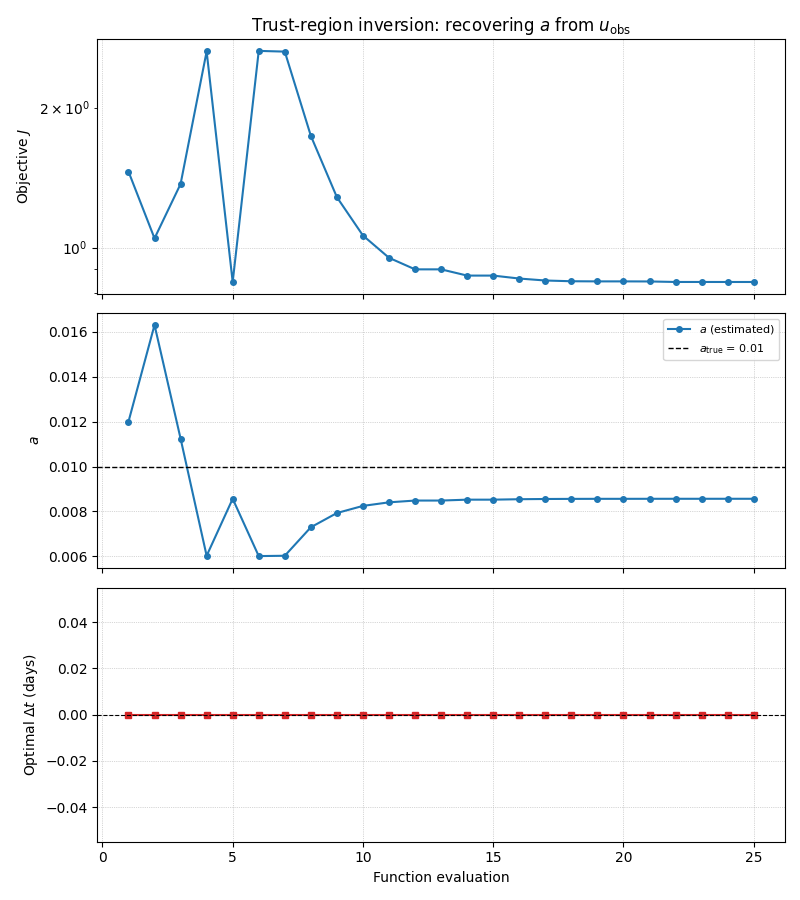

Final a = 0.00856628  (true = 0.01,  error = 14.3372%)
Final Dt = 0.000e+00 s  (0.00 days)


In [12]:
# ------------------------------------------------------------------
# Plot 4: trust-constr convergence (J, one panel per inverted param, Dt)
# ------------------------------------------------------------------
n_param_rows = len(INVERT_PARAMS)
n_rows       = 1 + n_param_rows + 1   # J + params + Dt
fig, axes = plt.subplots(n_rows, 1, figsize=(8, 3 * n_rows), sharex=True)

iters = np.arange(1, n_evals + 1)

axes[0].semilogy(iters, J_hist, 'o-', ms=4)
axes[0].set_ylabel('Objective $J$')
param_str = ' + '.join(f'${p}$' for p in INVERT_PARAMS)
axes[0].set_title(f'Trust-region inversion: recovering {param_str} from $u_{{\\rm obs}}$')
axes[0].grid(True, ls=':', lw=0.5)

for row_idx, p in enumerate(INVERT_PARAMS):
    ax = axes[1 + row_idx]
    p_hist = param_hist[p][1:]   # drop initial value; align with iters
    p_true = _param_true[p]
    ax.plot(iters, p_hist, 'o-', ms=4, label=f'${p}$ (estimated)')
    ax.axhline(p_true, color='k', ls='--', lw=1.0,
               label=f'${p}_{{\\rm true}}$ = {p_true:.5g}')
    ax.set_ylabel(f'${p}$')
    ax.legend(fontsize=8)
    ax.grid(True, ls=':', lw=0.5)

axes[-1].plot(iters, [dt / 86400 for dt in dt_hist], 's-', ms=4, color='C3')
axes[-1].axhline(0, color='k', ls='--', lw=0.8)
axes[-1].set_ylabel('Optimal $\\Delta t$ (days)')
axes[-1].set_xlabel('Function evaluation')
axes[-1].grid(True, ls=':', lw=0.5)

plt.tight_layout()
plt.show()

for i, p in enumerate(INVERT_PARAMS):
    final_v = x_final[i]   # x_final = result.x * scales (physical units)
    true_v  = _param_true[p]
    print(f"Final {p} = {final_v:.6g}  (true = {true_v:.6g},  "
          f"error = {abs(final_v - true_v) / true_v * 100:.4f}%)")
print(f"Final Dt = {dt_hist[-1]:.3e} s  ({dt_hist[-1]/86400:.2f} days)")

Saving animation... this may take a moment.


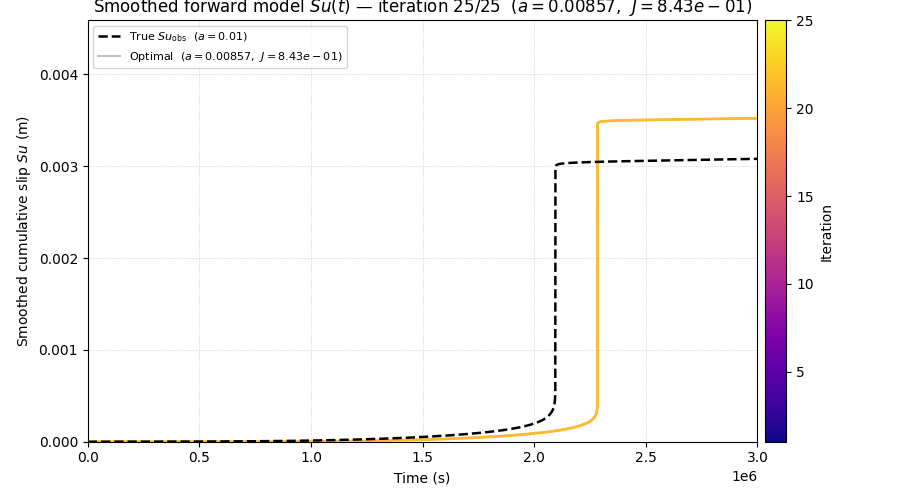

In [13]:
# Stop and close any animation left over from a previous run of this cell.
try:
    anim.event_source.stop()
    plt.close(fig_anim)
except (NameError, AttributeError):
    pass

# ------------------------------------------------------------------
# Plot 5 (animated): cycle through gradient descent iterations.
# ------------------------------------------------------------------
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Toggle: True  -> plot Su (smoothed slip, as used in the objective function)
#         False -> plot u  (raw cumulative slip)
PLOT_SMOOTHED = True

def _apply_smoothing(u, t):
    return make_smoothing_matrix(t, sigma_smooth) @ u

def _get_u_plot(u, t):
    return _apply_smoothing(u, t) if PLOT_SMOOTHED else u

def _get_uobs_plot(t):
    u_obs_interp = np.interp(t, t_obs_arr, u_obs)
    return _apply_smoothing(u_obs_interp, t) if PLOT_SMOOTHED else u_obs_interp

ylabel_str   = 'Smoothed cumulative slip $Su$ (m)' if PLOT_SMOOTHED else 'Cumulative slip $u$ (m)'
title_prefix = 'Smoothed forward model $Su(t)$'    if PLOT_SMOOTHED else 'Forward model $u(t)$'

# Index of the globally optimal evaluation (lowest J across all basin-hopping steps)
opt_idx = int(np.argmin(J_hist))

# Build label strings
_true_param_str = ',  '.join(f'${p}={_param_true[p]:.5g}$' for p in INVERT_PARAMS)
_opt_param_str  = ',  '.join(
    f'${p}={param_hist[p][opt_idx + 1]:.5f}$' for p in INVERT_PARAMS
)
obs_label = (f'True $Su_{{\\rm obs}}$  ({_true_param_str})'
             if PLOT_SMOOTHED else f'True  ({_true_param_str})')

fig_anim, ax_anim = plt.subplots(figsize=(9, 5))

t_opt = t_hist[opt_idx]
ax_anim.plot(t_opt, _get_uobs_plot(t_opt), 'k--', lw=1.8, label=obs_label, zorder=5)

line_opt, = ax_anim.plot(t_opt, _get_u_plot(u_hist[opt_idx], t_opt),
                          color='silver', lw=1.5, ls='-',
                          label=f'Optimal  ({_opt_param_str},  $J={J_hist[opt_idx]:.2e}$)',
                          zorder=2)

cmap_anim = plt.cm.plasma
line_curr, = ax_anim.plot([], [], lw=2.0, zorder=4)

sm = plt.cm.ScalarMappable(cmap=cmap_anim,
     norm=plt.Normalize(vmin=1, vmax=n_evals))
sm.set_array([])
cbar_anim = fig_anim.colorbar(sm, ax=ax_anim, pad=0.01)
cbar_anim.set_label('Iteration')

ax_anim.set_xlabel('Time (s)')
ax_anim.set_ylabel(ylabel_str)
ax_anim.grid(True, ls=':', lw=0.4, which='both')

all_u_plot = np.concatenate(
    [_get_u_plot(u, t) for u, t in zip(u_hist, t_hist)]
    + [_get_uobs_plot(t_opt)]
)
ax_anim.set_ylim(all_u_plot.min() * 0.95, all_u_plot.max() * 1.05)
ax_anim.set_xlim(t_obs_arr[0], t_obs_arr[-1])
ax_anim.legend(fontsize=8, loc='upper left')
title_obj = ax_anim.set_title('')

def _init():
    line_curr.set_data([], [])
    return line_curr, title_obj

def _update(frame):
    idx   = frame
    color = cmap_anim((idx) / max(n_evals - 1, 1) * 0.75 + 0.1)
    line_curr.set_data(t_hist[idx], _get_u_plot(u_hist[idx], t_hist[idx]))
    line_curr.set_color(color)
    # param_hist[p] = [init, eval_1, ..., eval_n]; idx+1 gives value at this eval
    _param_iter_str = ',  '.join(
        f'${p}={param_hist[p][idx + 1]:.5f}$' for p in INVERT_PARAMS
    )
    title_obj.set_text(
        f'{title_prefix} — iteration {idx+1}/{n_evals}  '
        f'({_param_iter_str},  $J={J_hist[idx]:.2e}$)'
    )
    return line_curr, title_obj

anim = FuncAnimation(
    fig_anim, _update,
    frames=n_evals,
    init_func=_init,
    interval=600,
    blit=True,
    repeat=True,
)

plt.tight_layout()
writer = 'ffmpeg'
print("Saving animation... this may take a moment.")
anim.save(
    'Figures/gradient_descent_evolution_adap_slip.gif',
    writer=writer,
    fps=8,
    dpi=100,
    bitrate=1000
)

HTML(anim.to_jshtml())